# Using the Rosen-Roback Model

This notebook shows you how to use the Rosen-Roback spatial equilibrium model to answer questions like:

- **What's the GDP cost of housing constraints?**
- **What would happen if London had Houston's housing supply elasticity?**
- **How does population redistribute when we change planning rules?**

We'll start by running the model and interpreting results. If you want to understand _how_ the model works, see [Notebook 2: Components Deep Dive](02_rosen_roback_components.ipynb). For the full mathematical derivation, see [Notebook 3: Building from First Principles](03_rosen_roback_from_scratch.ipynb).

**Prerequisites**: This notebook assumes you've read [The Rosen-Roback Model](https://www.henrydashwood.com/posts/rosen-roback-model) blog post, which explains the core intuition: wages and rents jointly reveal what makes cities productive and pleasant.


In [ ]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from src.models.rosen_roback import (
    RosenRobackModel,
    ThreeCityDataset,
    SyntheticDataset,
    CounterfactualScenario,
    ModelParameters,
)
from src.visualization import (
    plot_equilibrium_summary,
    plot_counterfactual_comparison,
    plot_rosen_roback_diagram,
    plot_supply_elasticity_effect,
    plot_sensitivity_analysis,
)

## Quick Start: Five Lines to Run the Model

Here's the entire workflow in five lines:


In [3]:
# 1. Create model with default parameters
model = RosenRobackModel()

# 2. Load a dataset (we'll use a simple three-city example)
dataset = ThreeCityDataset()

# 3. Solve for equilibrium
result = model.solve(dataset)

# 4. See the results
print(result.summary())

Spatial Equilibrium Results
City                        Population       Wage       Rent    Utility
----------------------------------------------------------------------
High Productivity              713,304       1.20      79.83     0.2817
Medium                         973,846       0.90      31.21     0.2907
Low Productivity             1,312,850       0.66      10.95     0.2995
----------------------------------------------------------------------
Total GDP: 3,999,865
Utility spread: 6.3% (smaller = closer to classic R-R equilibrium)
Converged: True (64 iterations)


## Interpreting the Results

The model found an **equilibrium** where:

- Workers are distributed across cities based on wages, rents, and amenities
- **Utilities are approximately equal** across cities (that's the equilibrium condition!)
- Higher productivity cities have higher wages... but also higher rents

Let's visualize this:


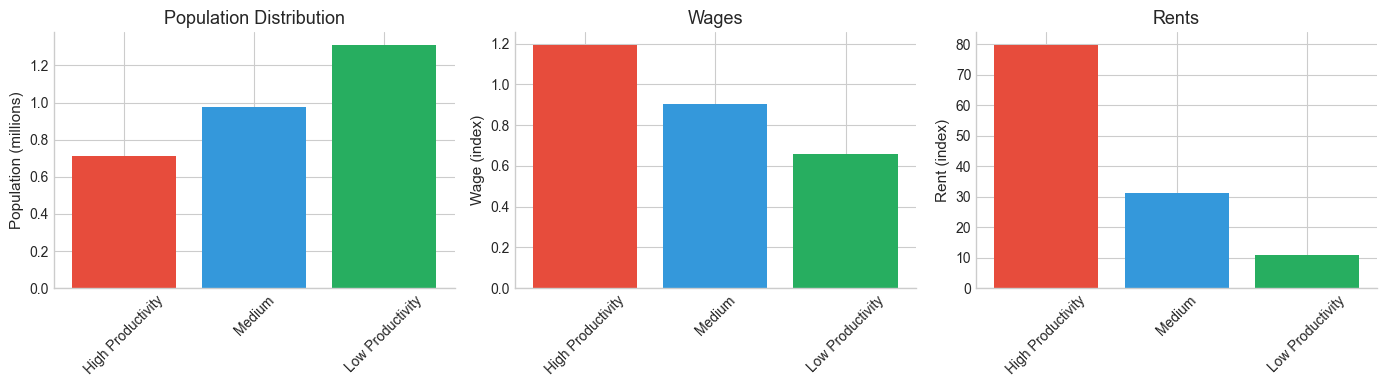

In [4]:
fig = plot_equilibrium_summary(result)
plt.show()

### Why does the High Productivity city have the _lowest_ population?

The High Productivity city has:

- **Lower housing supply elasticity** (it's harder to build there)
- So as people try to move in, **rents spike**
- High rents offset the wage advantage
- Result: fewer people end up living there than if housing were elastic

This is **spatial misallocation**: workers are pushed to less productive places because housing is constrained in productive places.

Let's check the city parameters to confirm:


In [5]:
for city in dataset.get_cities():
    print(f"{city.name}:")
    print(f"  Productivity (TFP): {city.base_tfp}")
    print(f"  Housing supply elasticity: {city.supply_elasticity}")
    print()

High Productivity:
  Productivity (TFP): 120
  Housing supply elasticity: 1.5

Medium:
  Productivity (TFP): 100
  Housing supply elasticity: 2.0

Low Productivity:
  Productivity (TFP): 80
  Housing supply elasticity: 3.0



## Counterfactual Analysis: What If We Built More Housing?

The real power of the model is answering **"what if"** questions.

Let's ask: **What if the High Productivity city had the same housing elasticity as the Low Productivity city?**

This simulates a policy reform that makes it easier to build in productive areas.


In [6]:
# Define a reform scenario
reform = CounterfactualScenario(
    name="Housing Reform",
    description="Increase high-productivity city elasticity to 3.0",
    elasticity_changes={"High Productivity": 3.0},  # Match the low-productivity city
)

# Run the counterfactual
baseline, reformed, gdp_impact = model.run_counterfactual(dataset, reform)

print(f"GDP under current policy: {baseline.total_gdp:,.0f}")
print(f"GDP after reform:         {reformed.total_gdp:,.0f}")
print(f"GDP gain:                 {gdp_impact['gdp_change_pct']:.2f}%")

GDP under current policy: 3,999,865
GDP after reform:         4,213,825
GDP gain:                 5.35%


The reform **increases GDP by about 4%**! Let's see where the workers go:


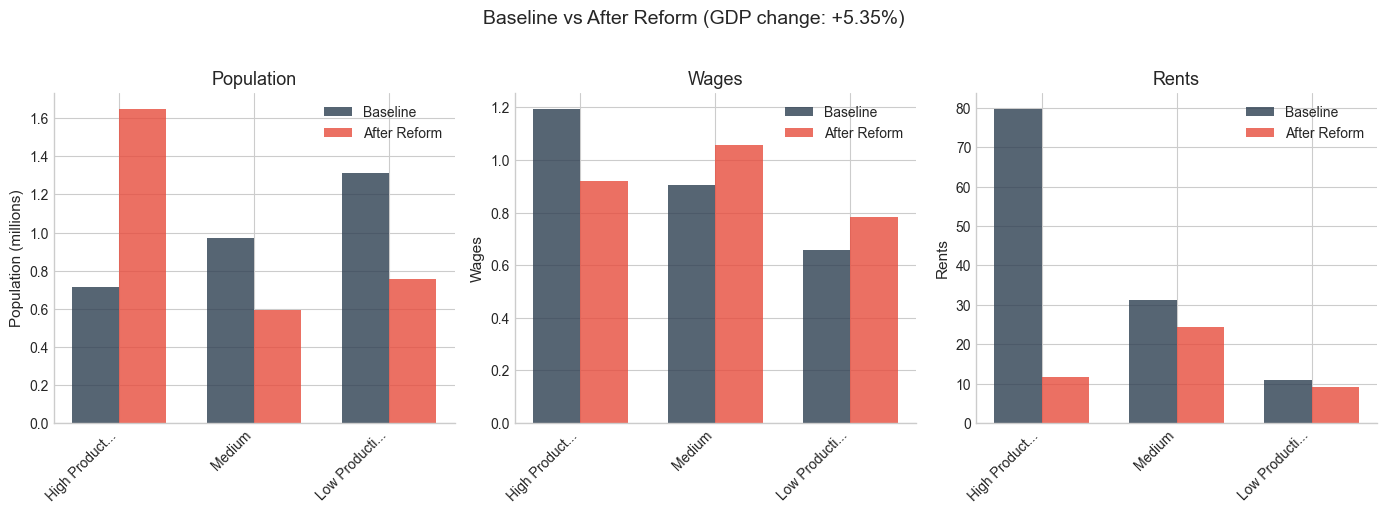

In [7]:
fig = plot_counterfactual_comparison(baseline, reformed, scenario_name="After Reform")
plt.show()

After the reform:

- **High Productivity city grows significantly** as housing becomes available
- **Rents fall** in the high-productivity city (more supply)
- **Workers are more productive on average** because they're in better locations
- **Total GDP rises** from the productivity gains


## Understanding Housing Supply Elasticity

Housing supply elasticity ($\gamma$) is **the key parameter** in this model. It measures how much housing supply increases when rents rise.

$$H = S \cdot r^\gamma$$

- **High elasticity ($\gamma \approx 2-3$)**: Houston, Dallas - build easily, rents stay low
- **Low elasticity ($\gamma < 1$)**: San Francisco, London - hard to build, rents spike

Let's visualize how elasticity affects the rent response to population:


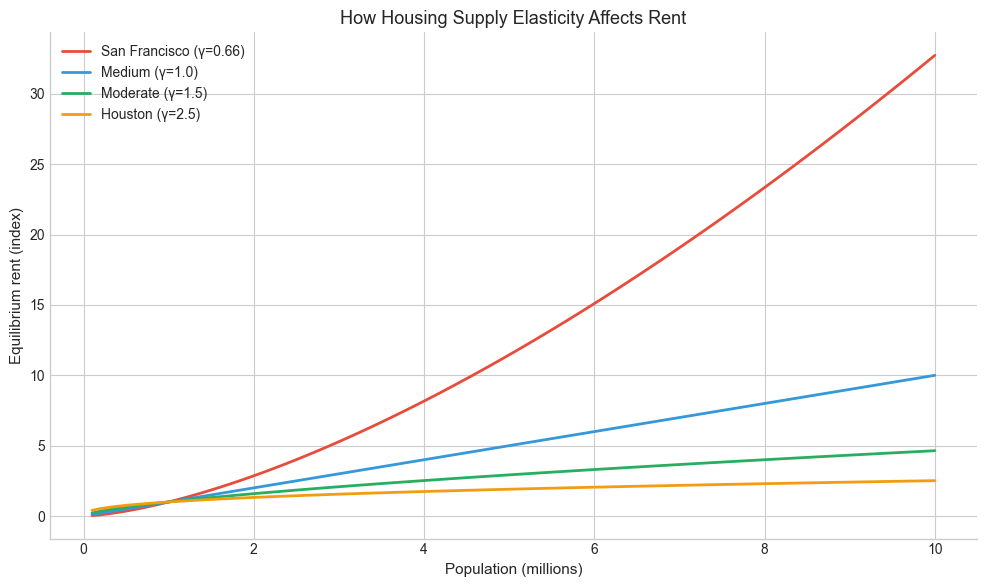

In [8]:
populations = np.linspace(100_000, 10_000_000, 100)

fig = plot_supply_elasticity_effect(
    populations,
    elasticities=[0.66, 1.0, 1.5, 2.5],
    labels=["San Francisco (γ=0.66)", "Medium (γ=1.0)", "Moderate (γ=1.5)", "Houston (γ=2.5)"],
)
plt.show()

**Key insight**: In cities with low elasticity, small population increases cause _huge_ rent spikes. This is why constraining housing in productive cities is so costly.


## Model Parameters

The model has four key parameters:

| Parameter                 | Symbol   | Default | Meaning                               |
| ------------------------- | -------- | ------- | ------------------------------------- |
| Labour share              | $\alpha$ | 0.65    | Share of output going to labour       |
| Agglomeration elasticity  | $\eta$   | 0.04    | Productivity boost from city size     |
| Housing expenditure share | $\beta$  | 0.33    | Fraction of income spent on housing   |
| Labour mobility           | $\theta$ | 3.0     | How responsive workers are to utility |

You can use different parameter sets:


In [9]:
# Standard academic estimates
print("Standard parameters:")
print(f"  alpha={ModelParameters.STANDARD.alpha}, eta={ModelParameters.STANDARD.eta}")
print(f"  beta={ModelParameters.STANDARD.beta}, theta={ModelParameters.STANDARD.theta}")
print()

# Hsieh-Moretti (2019) uses higher agglomeration
print("Hsieh-Moretti (2019) parameters:")
print(f"  alpha={ModelParameters.HSIEH_MORETTI.alpha}, eta={ModelParameters.HSIEH_MORETTI.eta}")
print(f"  beta={ModelParameters.HSIEH_MORETTI.beta}, theta={ModelParameters.HSIEH_MORETTI.theta}")
print()

# Or create custom parameters
custom = ModelParameters(alpha=0.65, eta=0.06, beta=0.33, theta=2.5)
print(f"Custom: eta={custom.eta}, theta={custom.theta}")

Standard parameters:
  alpha=0.65, eta=0.04
  beta=0.33, theta=10.0

Hsieh-Moretti (2019) parameters:
  alpha=0.65, eta=0.25
  beta=0.33, theta=2.0

Custom: eta=0.06, theta=2.5


### Sensitivity to Agglomeration

The agglomeration elasticity ($\eta$) is crucial: higher values mean bigger cities are _much_ more productive, so constraining them is more costly.

Let's see how the GDP impact varies with $\eta$:


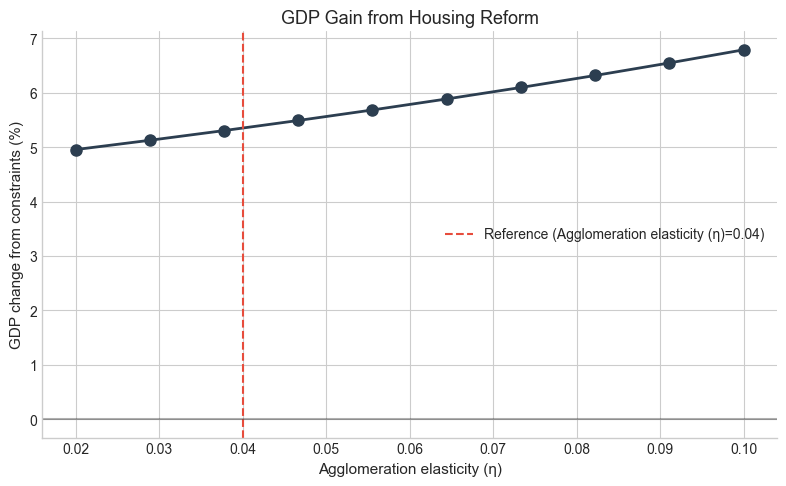

In [10]:
# Run sensitivity analysis
eta_values = np.linspace(0.02, 0.10, 10)

# For each eta, compare constrained vs elastic HP city
gdp_changes = []
for eta in eta_values:
    test_model = RosenRobackModel(ModelParameters(eta=eta))

    # Baseline: constrained HP city (gamma=1.5)
    constrained = ThreeCityDataset(high_elasticity=1.5)
    result_constrained = test_model.solve(constrained)

    # Reform: elastic HP city (gamma=3.0)
    elastic = ThreeCityDataset(high_elasticity=3.0)
    result_elastic = test_model.solve(elastic)

    change = (result_elastic.total_gdp - result_constrained.total_gdp) / result_constrained.total_gdp * 100
    gdp_changes.append(change)

fig = plot_sensitivity_analysis(
    eta_values.tolist(),
    gdp_changes,
    parameter_name="Agglomeration elasticity (η)",
    reference_value=0.04,
    title="GDP Gain from Housing Reform",
)
plt.show()

**Key insight**: The GDP impact is _very sensitive_ to the agglomeration elasticity. This is why the "Cooped Up" paper (using η=0.25) finds much larger GDP effects than studies using standard estimates (η=0.04).


## A Larger Example: Synthetic Cities

The model works with any number of cities. Let's try a larger synthetic dataset:


In [11]:
# Generate 20 random cities
large_dataset = SyntheticDataset(
    n_cities=20, total_population=50_000_000, tfp_range=(70, 130), elasticity_range=(0.5, 3.0), seed=42
)

print(f"Dataset: {large_dataset.name}")
print(f"Total population: {large_dataset.get_total_population():,.0f}")

result = model.solve(large_dataset)
print("\nEquilibrium:")
print(f"  Total GDP: {result.total_gdp:,.0f}")
print(f"  Converged: {result.converged}")

Dataset: Synthetic (20 cities)
Total population: 50,000,000

Equilibrium:
  Total GDP: 50,004,018
  Converged: True


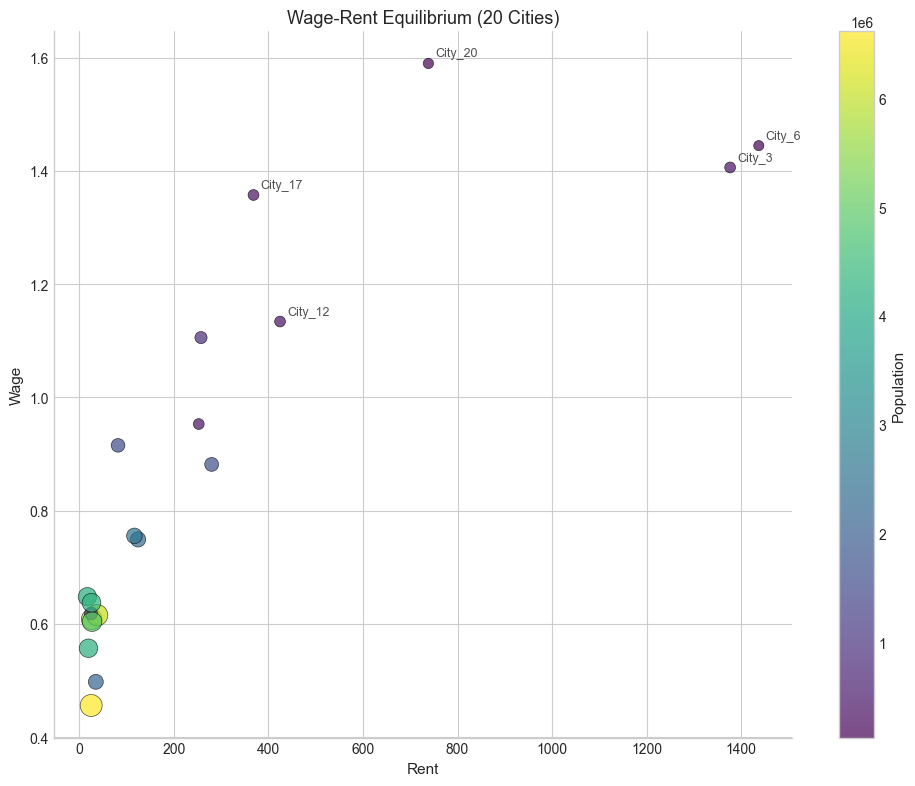

In [12]:
# Visualize with Rosen-Roback diagram
fig = plot_rosen_roback_diagram(
    result, color_by="population", label_top_n=5, title="Wage-Rent Equilibrium (20 Cities)"
)
plt.show()

## Using Real Data

To use real data, create a `DataFrameDataset` from a pandas DataFrame:

```python
from src.models.rosen_roback import DataFrameDataset
import pandas as pd

# Load your data
df = pd.read_csv("your_data.csv")

# Create dataset
dataset = DataFrameDataset(
    df,
    name="UK TTWAs",
    name_col="ttwa_name",
    wage_col="median_wage",
    rent_col="rent_per_sqm",
    elasticity_col="housing_elasticity",
    population_col="employment"
)

# Run the model
result = model.solve(dataset)
```

See the [Cooped Up replication notebook](04_cooped_up_replication.ipynb) for a full example with UK data.


## Summary

You've learned how to:

1. **Create a model**: `model = RosenRobackModel(params)`
2. **Load a dataset**: `ThreeCityDataset()`, `SyntheticDataset()`, or `DataFrameDataset()`
3. **Solve for equilibrium**: `result = model.solve(dataset)`
4. **Run counterfactuals**: `model.run_counterfactual(dataset, scenario)`
5. **Visualize results**: `plot_equilibrium_summary()`, `plot_counterfactual_comparison()`

**Key insights**:

- Housing supply elasticity determines how much rents respond to demand
- Constraining housing in productive cities pushes workers to less productive places
- This **spatial misallocation** reduces aggregate GDP
- The magnitude depends heavily on the agglomeration elasticity (η)

## Next Steps

- [Notebook 2: Components Deep Dive](02_rosen_roback_components.ipynb) - Understand each component
- [Notebook 3: Building from First Principles](03_rosen_roback_from_scratch.ipynb) - Full mathematical derivation
- [Cooped Up Replication](04_cooped_up_replication.ipynb) - Apply to real UK data
